# Haltestellen im Verkehrsverbund Steiermark

Univariate descriptive analysis for the master's thesis.

**Source:** OGD/Haltestellen.zip

In [ ]:
import os
import sys
os.chdir(r"D:\CO2_Masterarbeit\CO2_Masterarbeit")
sys.path.insert(0, r"D:\CO2_Masterarbeit\CO2_Masterarbeit\FIG")

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from plotting.apa7 import set_apa7_style, new_figure, save_apa7, add_north_arrow, BAR_KWARGS, HIST_KWARGS, LINE_KWARGS

set_apa7_style()

In [ ]:
stops = gpd.read_file("OGD/Public_Transport/Haltestellen_2025.zip")
stops["Abfahrten"].describe()

count     8221.000000
mean       112.688237
std        366.764479
min          0.000000
25%          3.000000
50%         14.000000
75%         63.000000
max      10322.000000
Name: Abfahrten, dtype: float64

## Scheduled departures per stop

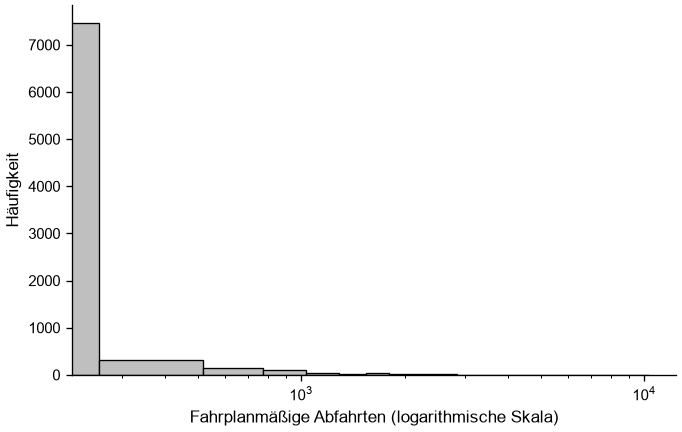

In [ ]:
fig, ax = new_figure()
ax.hist(stops["Abfahrten"].dropna(), bins=40, **HIST_KWARGS)
ax.set_xscale("log")
ax.set(xlabel="Fahrplanmäßige Abfahrten (logarithmische Skala)", ylabel="Häufigkeit")
save_apa7(fig, "FIG/Haltestellen/figure_1_departures_distribution.png")
save_apa7(fig, "FIG/Haltestellen/figure_1_departures_distribution.svg")
plt.show()

## Stops by tariff zone

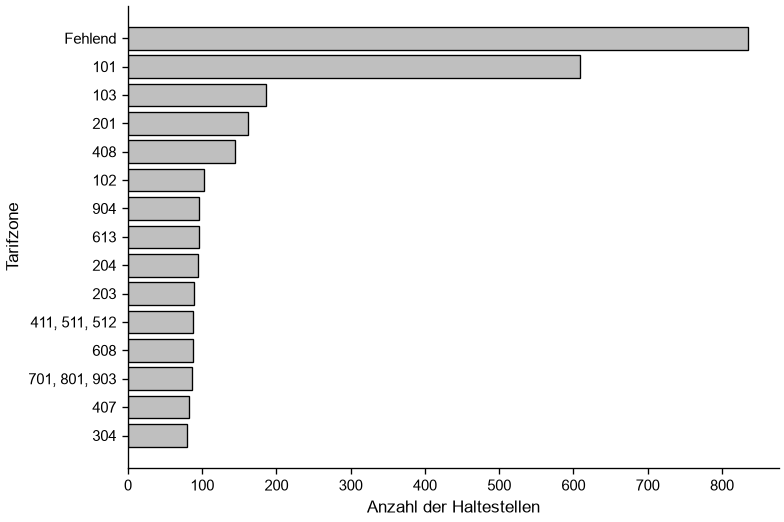

In [ ]:
counts = stops["TARIFZONEN"].fillna("Fehlend").value_counts().head(15).sort_values()
fig, ax = new_figure(7, 5)
ax.barh(counts.index, counts.values, **BAR_KWARGS)
ax.set(xlabel="Anzahl der Haltestellen", ylabel="Tarifzone")
save_apa7(fig, "FIG/Haltestellen/figure_2_stops_by_tariff_zone.png")
save_apa7(fig, "FIG/Haltestellen/figure_2_stops_by_tariff_zone.svg")
plt.show()

## Historical weekday frequencies

The annual GeoParquets are prepared in `OGD/Verbund_Daten_preparation.ipynb`. `weekday_avg_departures` is the unweighted mean of representative school and holiday Monday–Friday schedules.

In [ ]:
years = (2017, 2018, 2019, 2020, 2022, 2025) # 2016 Data incomplete
datasets = {year: gpd.read_parquet(f"OGD/Public_Transport/public_transport_weekday_stop_frequency_{year}.geoparquet") for year in years}
summary = pd.read_csv("OGD/Public_Transport/public_transport_weekday_frequency_summary.csv")
border = gpd.read_file("OGD/Gemeindegrenzen.zip", columns=[]).dissolve().to_crs(3857)
summary

,year,stops,located_stops,total_avg_departures,median_avg_departures,median_weekday_line_count,max_weekday_line_count
0,2016,4880,4785,161492.5,7.0,1.0,72
1,2017,7630,7562,225492.0,7.0,1.0,67
2,2018,7469,7444,217240.0,7.0,1.0,57
3,2019,7454,7426,234430.0,7.0,1.0,59
4,2020,7166,7117,238368.0,8.5,1.0,60
5,2022,7093,7081,255658.0,9.5,1.0,51


## Statewide yearly comparison

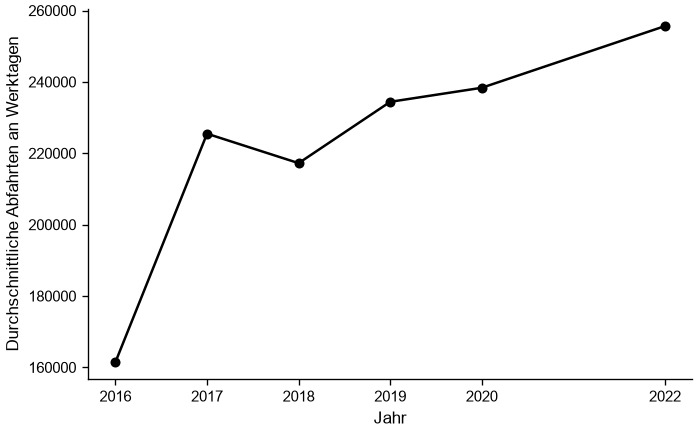

In [ ]:
fig, ax = new_figure()
ax.plot(summary["year"], summary["total_avg_departures"], marker="o", **LINE_KWARGS)
ax.set(xticks=summary["year"], xlabel="Jahr", ylabel="Durchschnittliche Abfahrten an Werktagen")
ax.ticklabel_format(axis="y", style="plain")
save_apa7(fig, "FIG/Haltestellen/figure_4_average_weekday_departures_by_year.png")
save_apa7(fig, "FIG/Haltestellen/figure_4_average_weekday_departures_by_year.svg")
plt.show()

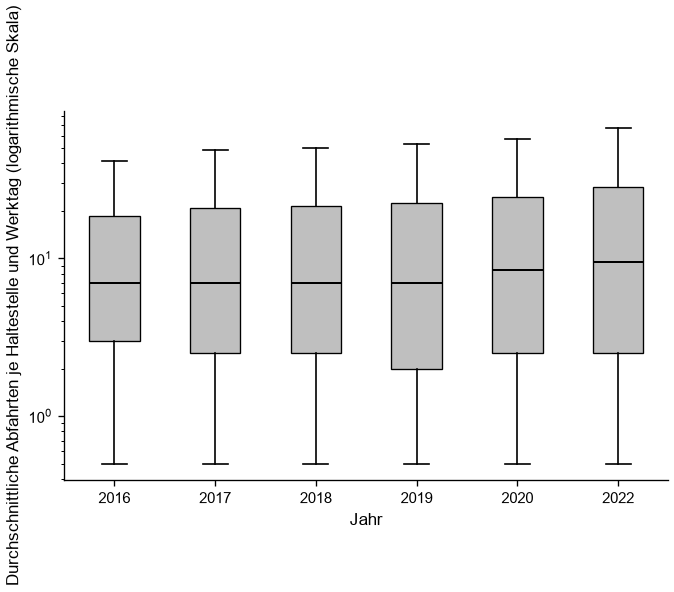

In [ ]:
fig, ax = new_figure()
values = [datasets[year]["weekday_avg_departures"].dropna().to_numpy() for year in years]
ax.boxplot(values, tick_labels=years, showfliers=False, patch_artist=True,
           boxprops={"facecolor": "0.75", "edgecolor": "black", "linewidth": 0.8},
           medianprops={"color": "black", "linewidth": 1.2}, whiskerprops={"color": "black"}, capprops={"color": "black"})
ax.set(yscale="log", xlabel="Jahr", ylabel="Durchschnittliche Abfahrten je Haltestelle und Werktag (logarithmische Skala)")
save_apa7(fig, "FIG/Haltestellen/figure_5_average_weekday_departures_distribution_by_year.png")
save_apa7(fig, "FIG/Haltestellen/figure_5_average_weekday_departures_distribution_by_year.svg")
plt.show()

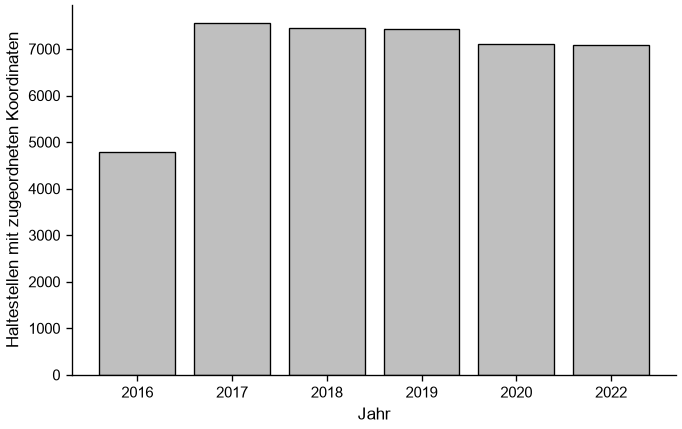

In [ ]:
fig, ax = new_figure()
ax.bar(summary["year"].astype(str), summary["located_stops"], **BAR_KWARGS)
ax.set(xlabel="Jahr", ylabel="Haltestellen mit zugeordneten Koordinaten")
save_apa7(fig, "FIG/Haltestellen/figure_6_stops_with_matched_coordinates_by_year.png")
save_apa7(fig, "FIG/Haltestellen/figure_6_stops_with_matched_coordinates_by_year.svg")
plt.show()

## Spatial distribution by year

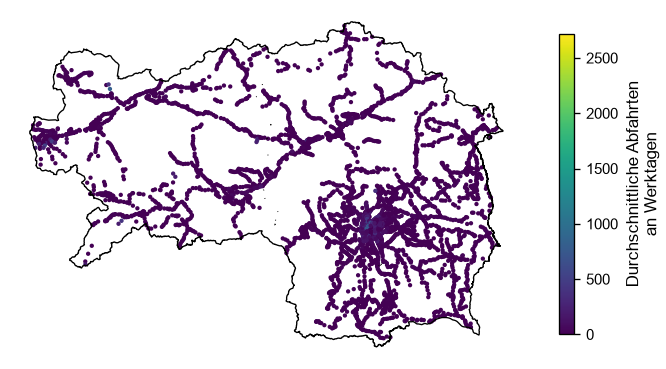

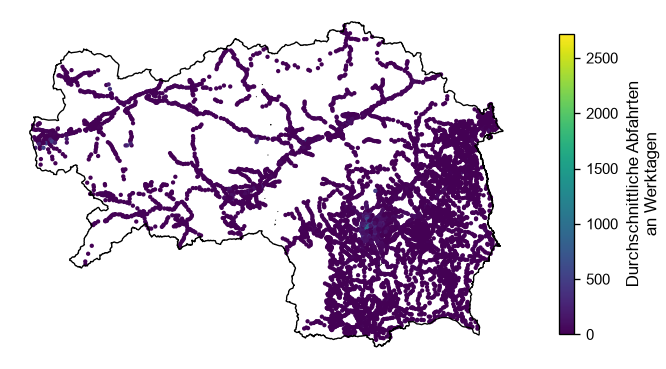

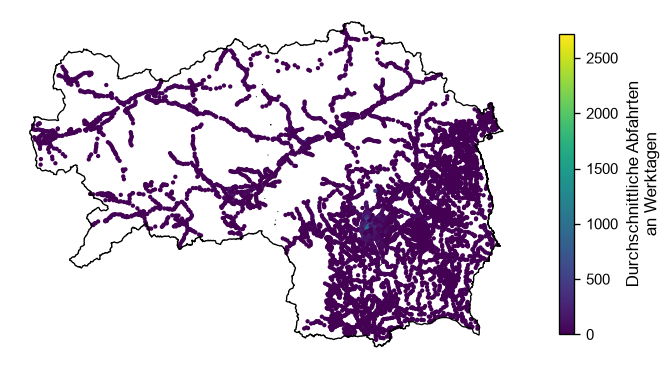

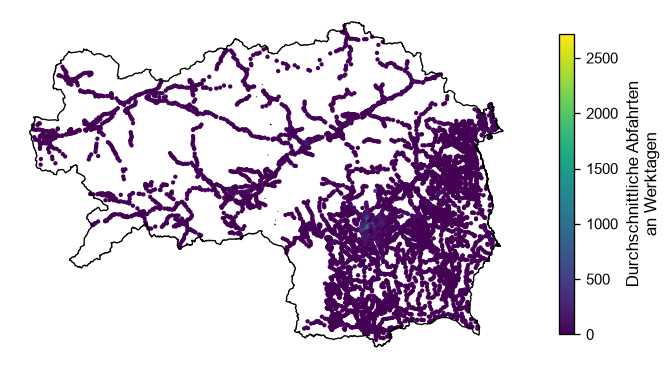

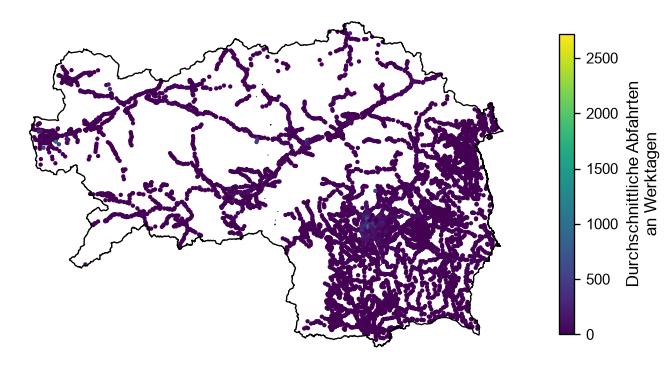

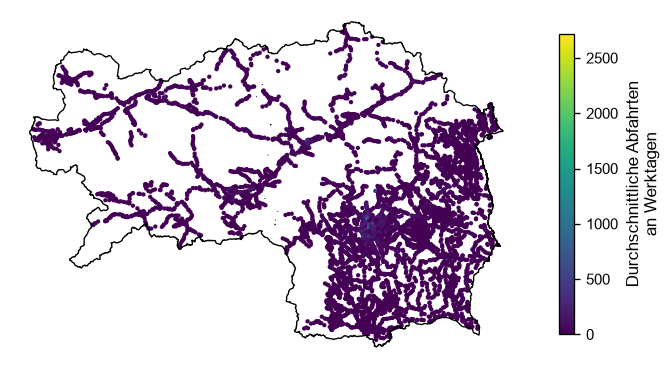

In [ ]:
max_departures = max(dataset["weekday_avg_departures"].max() for dataset in datasets.values())

for year, dataset in datasets.items():
    fig, ax = new_figure(7, 5)
    border.boundary.plot(ax=ax, color="black", linewidth=0.8)
    dataset[dataset["location_matched"]].plot(ax=ax, column="weekday_avg_departures", cmap="viridis", markersize=2.5,
                                               vmin=0, vmax=max_departures, legend=True,
                                               legend_kwds={"label": "Durchschnittliche Abfahrten\nan Werktagen", "shrink": 0.65}, rasterized=True)
    ax.set_axis_off()
    add_north_arrow(ax)
    save_apa7(fig, f"FIG/Haltestellen/figure_7_average_weekday_departures_map_{year}.png")
    save_apa7(fig, f"FIG/Haltestellen/figure_7_average_weekday_departures_map_{year}.svg")
    plt.show()

## Change between 2016 and 2022

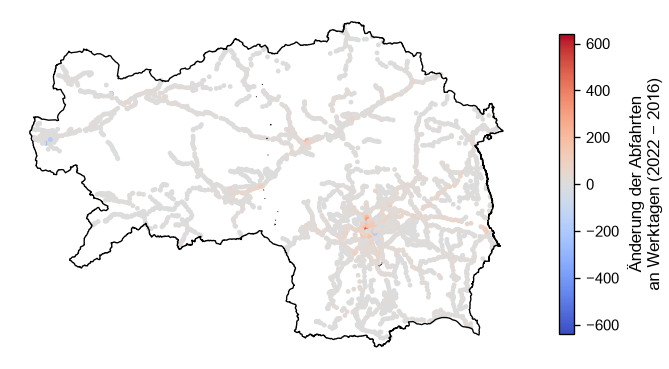

In [ ]:
baseline = datasets[2016][["station_id", "weekday_avg_departures"]].rename(columns={"weekday_avg_departures": "departures_2016"})
comparison = datasets[2022].merge(baseline, on="station_id", how="inner", validate="one_to_one")
comparison["departure_change_2016_2022"] = comparison["weekday_avg_departures"] - comparison["departures_2016"]
limit = comparison.loc[comparison["location_matched"], "departure_change_2016_2022"].abs().max()

fig, ax = new_figure(7, 5)
border.boundary.plot(ax=ax, color="black", linewidth=0.8)
comparison[comparison["location_matched"]].plot(ax=ax, column="departure_change_2016_2022", cmap="coolwarm", markersize=3.5,
                                                vmin=-limit, vmax=limit, legend=True,
                                                legend_kwds={"label": "Änderung der Abfahrten\nan Werktagen (2022 − 2016)", "shrink": 0.65}, rasterized=True)
ax.set_axis_off()
add_north_arrow(ax)
save_apa7(fig, "FIG/Haltestellen/figure_8_average_weekday_departures_change_2016_2022_map.png")
save_apa7(fig, "FIG/Haltestellen/figure_8_average_weekday_departures_change_2016_2022_map.svg")
plt.show()